In [1]:
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from src.preprocessing.blank import BlankDetector

In [2]:
TEST_IMAGE_DIR = Path("test/dataset/images")
TEST_CSV_PATH  = Path("test/dataset/labels.csv")
MODEL_PATH     = "models/rf_blank_detector.joblib"

In [3]:
df_test = pd.read_csv(TEST_CSV_PATH)
print(f"{len(df_test)} lines")

test_images = []
labels = []
filenames = []

for _, row in df_test.iterrows():
    img_path = TEST_IMAGE_DIR / row["filename"]
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"err: {img_path}")
        continue
    
    test_images.append(img)
    labels.append(row["is_blank"])
    filenames.append(row["filename"])

labels = np.array(labels, dtype=int)

5000 lines


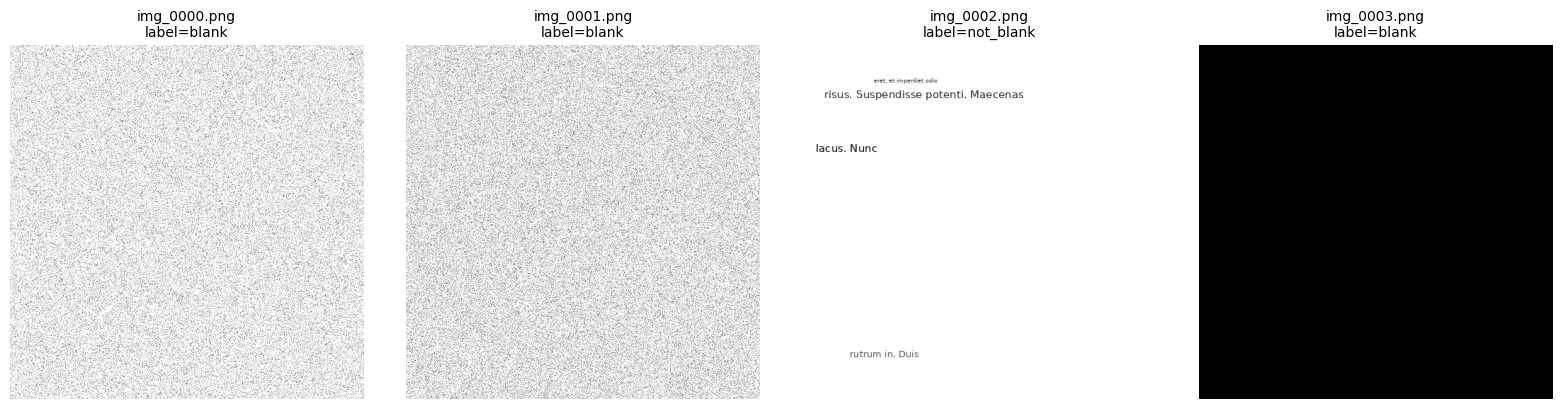

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, lbl, name in zip(axes, test_images[:4], labels[:4], filenames[:4]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{name}\nlabel={'blank' if lbl else 'not_blank'}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
bd = BlankDetector(model_path=MODEL_PATH)

In [6]:
predictions = []
scores = []
reasons = []
times_ms = []

for img in test_images:
    t0 = time.perf_counter()
    is_blank, score, reason = bd.is_blank(img)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    
    predictions.append(int(is_blank))
    scores.append(score)
    reasons.append(reason)
    times_ms.append(elapsed_ms)

predictions = np.array(predictions, dtype=int)
scores = np.array(scores)
times_ms = np.array(times_ms)

print(f"✓ Đã predict {len(predictions)} ảnh")
print(f"  - Tốc độ trung bình: {times_ms.mean():.2f} ms/ảnh")
print(f"  - Tốc độ p95:        {np.percentile(times_ms, 95):.2f} ms/ảnh")
print(f"  - Tốc độ max:        {times_ms.max():.2f} ms/ảnh")

✓ Đã predict 5000 ảnh
  - Tốc độ trung bình: 6.71 ms/ảnh
  - Tốc độ p95:        7.68 ms/ảnh
  - Tốc độ max:        11.53 ms/ảnh


In [7]:
# Đếm xem bao nhiêu case đi qua mỗi nhánh
fast_path_count = sum(1 for r in reasons if r.startswith("density"))
ml_path_count   = sum(1 for r in reasons if r.startswith("rf_model"))

print(f"Fast path (density): {fast_path_count} ({100*fast_path_count/len(reasons):.1f}%)")
print(f"ML path  (rf_model): {ml_path_count} ({100*ml_path_count/len(reasons):.1f}%)")

Fast path (density): 0 (0.0%)
ML path  (rf_model): 5000 (100.0%)


In [8]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    labels, predictions,
    target_names=["not_blank", "blank"],
    digits=4,
))

print(f"Overall accuracy: {accuracy_score(labels, predictions):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   not_blank     0.9989    0.9277    0.9620      1992
       blank     0.9543    0.9993    0.9763      3008

    accuracy                         0.9708      5000
   macro avg     0.9766    0.9635    0.9691      5000
weighted avg     0.9721    0.9708    0.9706      5000

Overall accuracy: 0.9708


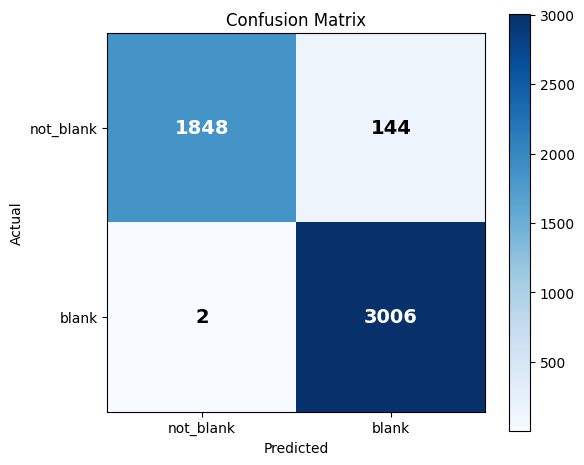


False Positive (not_blank → blank): 144
False Negative (blank → not_blank): 2


In [9]:
cm = confusion_matrix(labels, predictions)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["not_blank", "blank"])
ax.set_yticklabels(["not_blank", "blank"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# Ghi số lên mỗi ô
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"\nFalse Positive (not_blank → blank): {cm[0, 1]}")
print(f"False Negative (blank → not_blank): {cm[1, 0]}")

Tổng số case sai: 146/5000


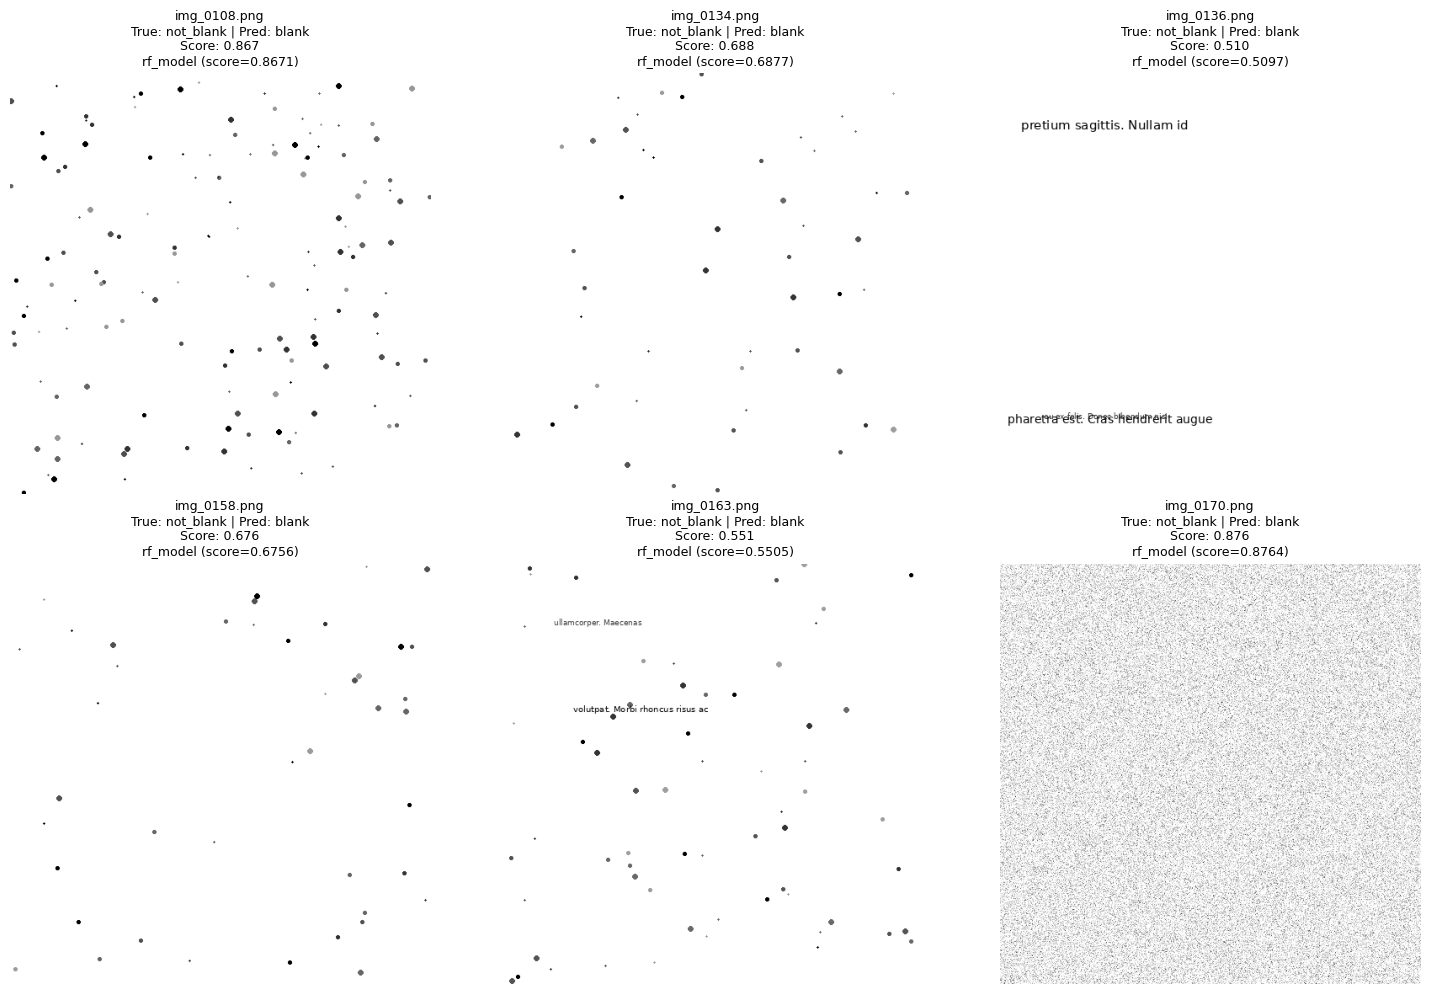

In [10]:
wrong_indices = np.where(predictions != labels)[0]
print(f"Tổng số case sai: {len(wrong_indices)}/{len(labels)}")

if len(wrong_indices) > 0:
    n_show = min(6, len(wrong_indices))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for ax, idx in zip(axes.flat, wrong_indices[:n_show]):
        ax.imshow(test_images[idx], cmap='gray')
        ax.set_title(
            f"{filenames[idx]}\n"
            f"True: {'blank' if labels[idx] else 'not_blank'} | "
            f"Pred: {'blank' if predictions[idx] else 'not_blank'}\n"
            f"Score: {scores[idx]:.3f}\n"
            f"{reasons[idx]}",
            fontsize=9,
        )
        ax.axis('off')
    
    for ax in axes.flat[n_show:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("🎉 Không có case nào sai!")

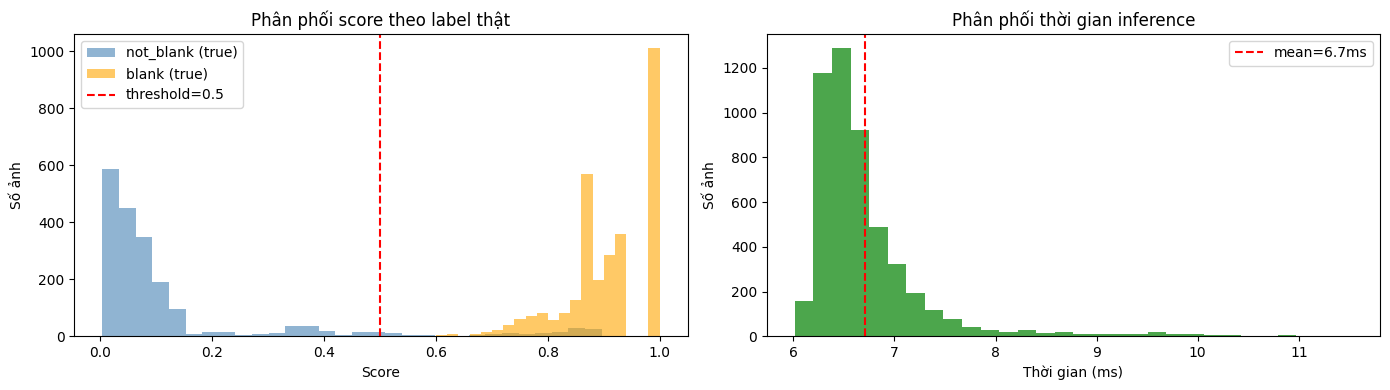

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram score theo label thật
axes[0].hist(scores[labels == 0], bins=30, alpha=0.6, label='not_blank (true)', color='steelblue')
axes[0].hist(scores[labels == 1], bins=30, alpha=0.6, label='blank (true)', color='orange')
axes[0].axvline(bd.threshold, color='red', linestyle='--', label=f'threshold={bd.threshold}')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Số ảnh')
axes[0].set_title('Phân phối score theo label thật')
axes[0].legend()

# Tốc độ
axes[1].hist(times_ms, bins=30, color='green', alpha=0.7)
axes[1].axvline(times_ms.mean(), color='red', linestyle='--', label=f'mean={times_ms.mean():.1f}ms')
axes[1].set_xlabel('Thời gian (ms)')
axes[1].set_ylabel('Số ảnh')
axes[1].set_title('Phân phối thời gian inference')
axes[1].legend()

plt.tight_layout()
plt.show()